<a href="https://colab.research.google.com/github/ASHIKAJAN/ABC-staff-company/blob/main/COPY_OF_MODULE_END.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [3]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.tab.txt to diabetes.tab.txt


In [4]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [5]:
print(df.isnull().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [6]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.80050009  1.06548848  1.29708846  0.45984057 -0.92974581 -0.73206462
  -0.91245053 -0.05449919  0.41853093 -0.37098854]
 [-0.03956713 -0.93853666 -1.08218016 -0.55350458 -0.17762425 -0.40288615
   1.56441355 -0.83030083 -1.43658851 -1.93847913]
 [ 1.79330681  1.06548848  0.93453324 -0.1192138  -0.95867356 -0.71889748
  -0.68024452 -0.05449919  0.06015558 -0.54515416]
 [-1.87244107 -0.93853666 -0.24377122 -0.77064997  0.25629203  0.52539714
  -0.75764652  0.72130245  0.47698252 -0.19682291]
 [ 0.11317236 -0.93853666 -0.76494435  0.45984057  0.08272552  0.32789006
   0.17117751 -0.05449919 -0.67250161 -0.98056821]]


In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.

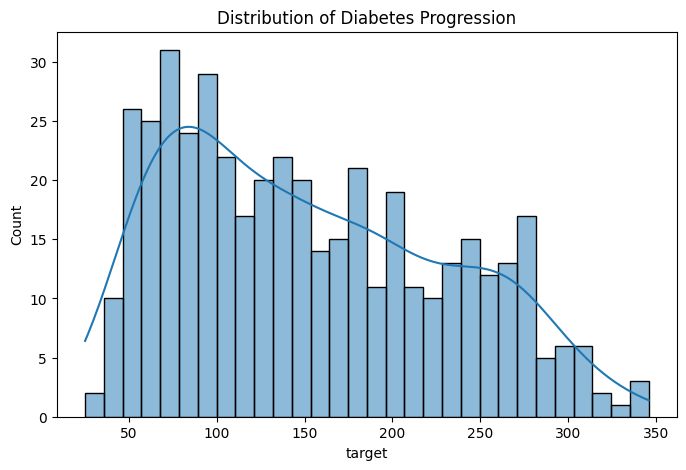

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of Diabetes Progression")
plt.show()

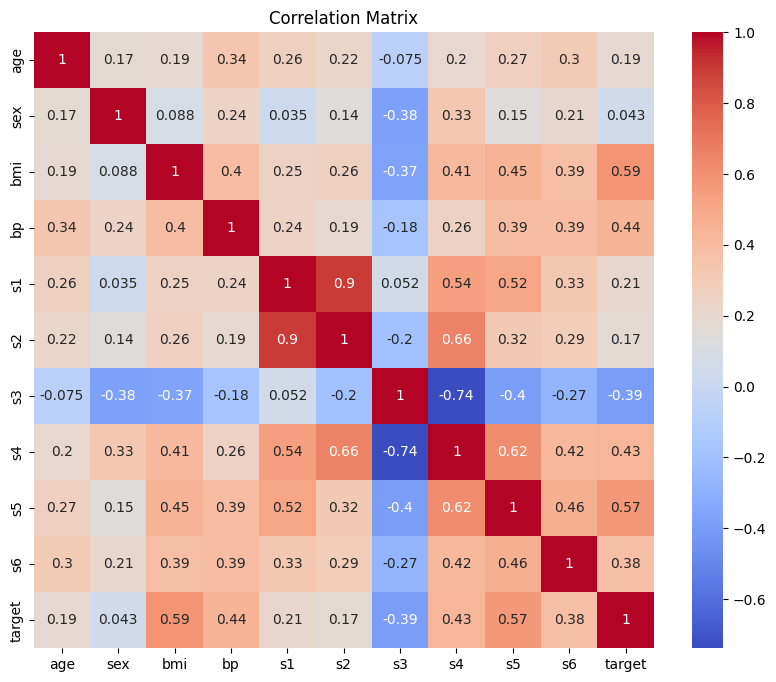

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

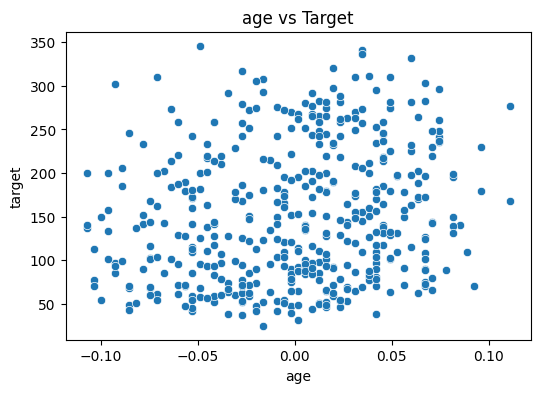

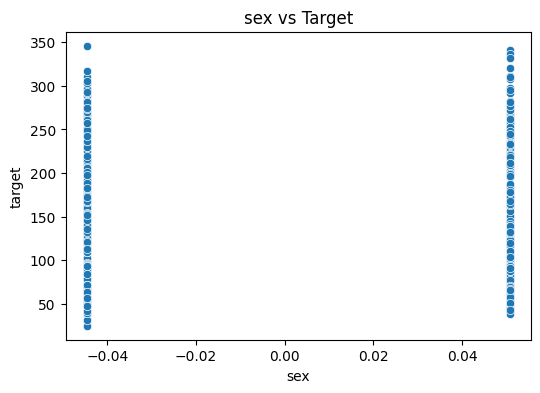

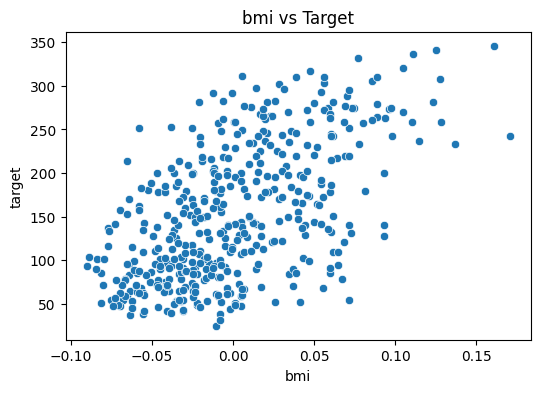

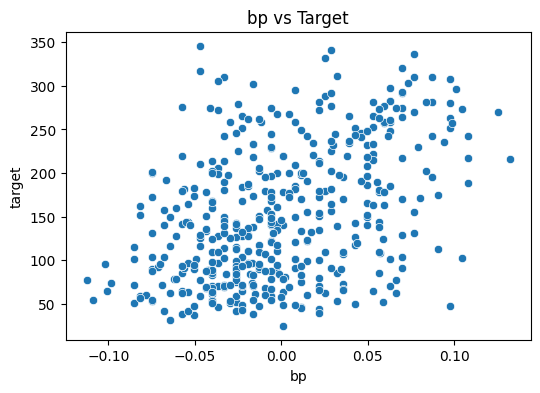

In [10]:
for col in diabetes.feature_names[:4]:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['target'])
    plt.title(f"{col} vs Target")
    plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [12]:
model = Sequential()

model.add(Dense(64,
                activation='relu',
                input_shape=(X_train.shape[1],)))

model.add(Dense(32,
                activation='relu'))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 31409.8574 - mae: 158.2151 - val_loss: 22216.5859 - val_mae: 133.0184
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 31040.0391 - mae: 156.9831 - val_loss: 21855.1484 - val_mae: 131.6266
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 30489.6309 - mae: 155.1862 - val_loss: 21286.2031 - val_mae: 129.4306
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29547.4609 - mae: 152.2248 - val_loss: 20362.5703 - val_mae: 125.8604
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 28047.5410 - mae: 147.3238 - val_loss: 18981.7402 - val_mae: 120.5164
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25773.8496 - mae: 139.9639 - val_loss: 17096.3379 - val_mae: 112.9987
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22785.8711 - mae: 129.7522 - val_loss: 14716.0352 - val_mae: 103.0071
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18919.0840 - mae: 116.2416 - val_loss

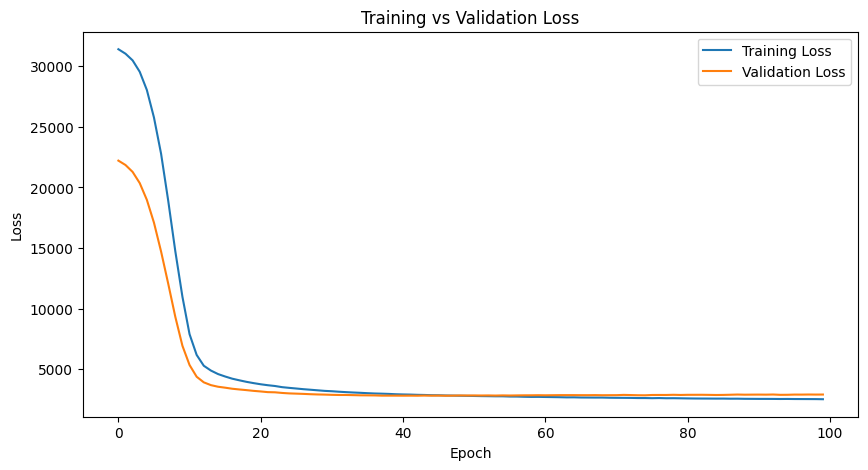

In [15]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [16]:
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Mean Squared Error: 2899.9446807934755
R² Score: 0.45264975062191937


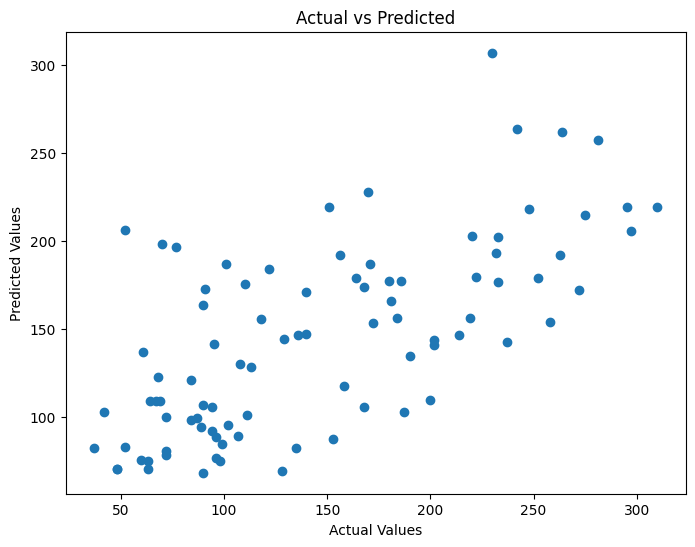

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,
            predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

In [18]:
improved_model = Sequential()

improved_model.add(Dense(128,
                         activation='relu',
                         input_shape=(X_train.shape[1],)))

improved_model.add(Dense(64,
                         activation='relu'))

improved_model.add(Dense(32,
                         activation='relu'))

improved_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
improved_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

In [20]:
history2 = improved_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 31382.7207 - mae: 158.2335 - val_loss: 22171.9199 - val_mae: 132.9459
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30626.2617 - mae: 155.9151 - val_loss: 21150.4082 - val_mae: 129.2170
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27992.3242 - mae: 147.8453 - val_loss: 17948.7051 - val_mae: 117.1950
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20852.4453 - mae: 124.1674 - val_loss: 11195.7637 - val_mae: 87.1328
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10259.7344 - mae: 80.8336 - val_loss: 4735.0845 - val_mae: 50.3467
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5648.5806 - mae: 58.6999 - val_loss: 3527.8035 - val_mae: 44.6787
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4711.8628 - mae: 54.4431 - val_loss: 3351.0164 - val_mae: 43.1912
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4266.0503 - mae: 51.8391 - val_loss: 3217.1833 - v

In [21]:
pred2 = improved_model.predict(X_test)

mse2 = mean_squared_error(y_test, pred2)
r22 = r2_score(y_test, pred2)

print("Improved Model MSE:", mse2)
print("Improved Model R²:", r22)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Improved Model MSE: 2841.7212386446627
Improved Model R²: 0.46363913803709
